Step1
# Import Libraries
# We load tools we need later.

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Libraries loaded!")

Libraries loaded!


Step 2: Load Raw Data
Read the CSV file into a table called df.
# read_excelread_parquet

In [3]:
df = pd.read_csv('TSLA.csv') 

print("Raw data loaded!")
print("Rows:", len(df), "| Columns:", len(df.columns))
df.head()

Raw data loaded!
Rows: 2956 | Columns: 7


,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [1]:
print("Hello")

Hello


Step3: First Look - Size and Basic info

In [4]:
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)


Shape (rows, columns): (2956, 7)

Column names: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:
Date             str
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


Step 4: Check Missing Values
Questions: Are there empty cells?
If yes, we must fill or remove them

In [5]:
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing:", missing.sum())

Missing values in each column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Total missing: 0


Step5: Check Duplicate Rows
Question: Is the same row repeated?

In [6]:
dup_all = df.duplicated().sum()
dup_dates = df.duplicated(subset=['Date']).sum()
print(df.info())
print("Duplicate rows:", dup_all)
print("Duplicate dates:", dup_dates)

<class 'pandas.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   str    
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 161.8 KB
None
Duplicate rows: 0
Duplicate dates: 0


Step6: Fix Data Types
Date should be date type (not plain text).

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

print("Date column fixed!")
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())

Date column fixed!
Date range: 2010-06-29 to 2022-03-24


Step7: Remove Duplicates and sort
even if duplicates are 0, it is a good practice.

In [8]:
before = len(df)

df = df.drop_duplicates(subset=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

after = len(df)
print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Removed:     {before - after}")

Rows before: 2956
Rows after:  2956
Removed:     0


Step8: Logic Checks (Very Important)
Remove rows that are impossible in stock data:
* price should be > 0
* High should be >= low
*Volume should be > 0

In [9]:
before = len(df)

df = df[df['Close'] > 0]
df = df[df['Open'] > 0]
df = df[df['High'] >= df['Low']]
df = df[df['Volume'] > 0]

after = len(df)
print(f"Bad rows removed: {before - after}")
print(f"Clean rows left:  {after}")

Bad rows removed: 0
Clean rows left:  2956


Step9: Create Helpful New columns
New columns can help analysis later

In [10]:
df['Year'] = df['Date'].dt.year
df['Price_Range'] = df['High'] - df['Low']

print("New columns added: Year, Price_Range")
df[['Date', 'Open', 'Close', 'Year', 'Price_Range']].head()

New columns added: Year, Price_Range


,Date,Open,Close,Year,Price_Range
0,2010-06-29,3.800,4.778,2010,1.492
1,2010-06-30,5.158,4.766,2010,1.424
2,2010-07-01,5.000,4.392,2010,1.130
3,2010-07-02,4.600,3.840,2010,0.878
4,2010-07-06,4.000,3.222,2010,0.834


Step10: Final Cleaning Check
After cleaning, always verify again.

In [11]:
print("=== CLEAN DATA REPORT ===")
print("Rows:", len(df))
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())
print("Negative Close prices:", (df['Close'] < 0).sum())
print("High < Low rows:", (df['High'] < df['Low']).sum())
print("\nBasic stats:")
df[['Open', 'High', 'Low', 'Close', 'Volume']].describe()

=== CLEAN DATA REPORT ===
Rows: 2956
Missing values: 0
Duplicates: 0
Negative Close prices: 0
High < Low rows: 0

Basic stats:


,Open,High,Low,Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,3.046940e+08


Step 11: Quick Visual Check
Plot once to see if data looks normal

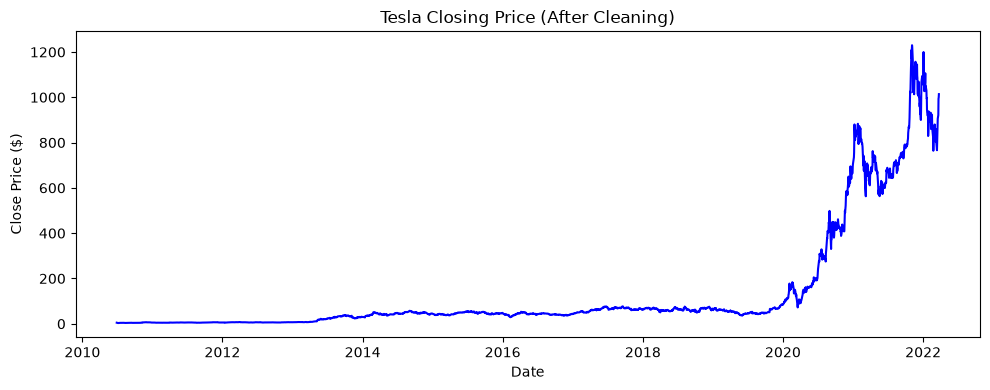

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(df['Date'], df['Close'], color='blue')
plt.title('Tesla Closing Price (After Cleaning)')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.tight_layout()
plt.show()

Step12: Save Clean Data (Optional)


In [13]:
df.to_csv('TSLA_clean.csv', index=False)
print("Saved as TSLA_clean.csv")

Saved as TSLA_clean.csv


PART B-Model building (step by step)
Now we can use clean data to predict Close price.

Step 13: Choose X and y
X=input features (what we know)
y=target (what we want to predict)
We start simple: predict Close using only Open

In [14]:
X = df[['Open']]
y = df['Close']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2956, 1)
y shape: (2956,)


Step 14: Split Data- Train and test
80 % train- model learns
20% test - we check performance

Like: study 80% questions, exam on 20%.


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 2364
Testing rows: 592


Step 15: Train Simple Linear Regression Model
Model 1: Open --Close

In [16]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("Model 1 trained!")
print(f"Formula: Close = {model1.intercept_:.2f} + {model1.coef_[0]:.2f} * Open")

Model 1 trained!
Formula: Close = 0.22 + 1.00 * Open


Step 16: Predict and Check Score (R2)
R2 score meaning
Near 1.0 = very poor
Near 0.0= poor


In [17]:
y_pred1 = model1.predict(X_test)
score1 = r2_score(y_test, y_pred1)

print("Model 1 (Open -> Close)")
print("R² Score:", round(score1, 4))

Model 1 (Open -> Close)
R² Score: 0.9989


Step17: Plot Actual vs Predicted (Model 1)

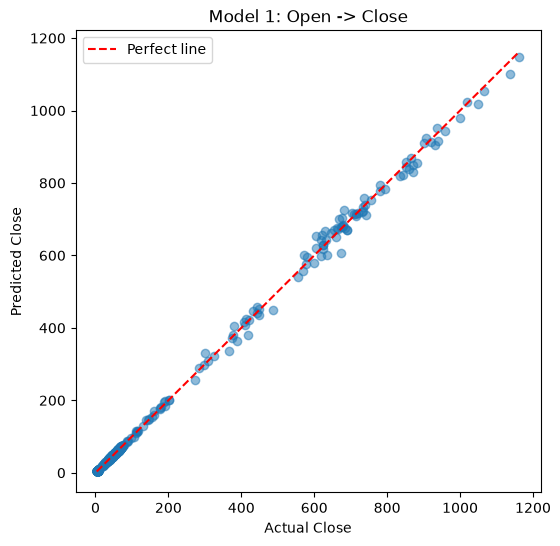

In [18]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred1, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect line')
plt.xlabel('Actual Close')
plt.ylabel('Predicted Close')
plt.title('Model 1: Open -> Close')
plt.legend()
plt.show()

Step 18: Train Better Model (Mutiple Features)
Model2: Use Open + High + Low to predict Close.
From our analysis guide: these 3 columns are strongly linked to Close.

In [19]:
X2 = df[['Open', 'High', 'Low']]
y2 = df['Close']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)
y_pred2 = model2.predict(X_test2)
score2 = r2_score(y_test2, y_pred2)

print("Model 2 (Open + High + Low -> Close)")
print("R² Score:", round(score2, 4))

Model 2 (Open + High + Low -> Close)
R² Score: 0.9996


Step 19 : Compare both Models

In [20]:
comparison = pd.DataFrame({
    'Model': ['Model 1 (Open)', 'Model 2 (Open+High+Low)'],
    'Features Used': ['Open', 'Open, High, Low'],
    'R2 Score': [round(score1, 4), round(score2, 4)]
})

comparison

,Model,Features Used,R2 Score
0,Model 1 (Open),Open,0.9989
1,Model 2 (Open+High+Low),"Open, High, Low",0.9996


Step20: Try One Prediction (Example)
Suppose opening price= 700, high = 710, low =690.
What closing price does model 2 predict?

In [21]:
sample = pd.DataFrame({'Open': [700], 'High': [710], 'Low': [690]})
predicted_close = model2.predict(sample)[0]

print(f"Predicted Close Price: ${predicted_close:.2f}")

Predicted Close Price: $700.40


Model with 70% test data 
check what amount of test data gives best accuracy

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 2069
Testing rows: 887


In [25]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("Model 1 trained!")
print(f"Formula: Close = {model1.intercept_:.2f} + {model1.coef_[0]:.2f} * Open")

Model 1 trained!
Formula: Close = 0.24 + 1.00 * Open


In [26]:
y_pred1 = model1.predict(X_test)
score1 = r2_score(y_test, y_pred1)

print("Model 1 (Open -> Close)")
print("R² Score:", round(score1, 4))

Model 1 (Open -> Close)
R² Score: 0.9987


Model with 60% test data 
check what amount of test data gives best accuracy

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 1773
Testing rows: 1183


In [28]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

print("Model 1 trained!")
print(f"Formula: Close = {model1.intercept_:.2f} + {model1.coef_[0]:.2f} * Open")

Model 1 trained!
Formula: Close = 0.24 + 1.00 * Open


In [29]:
y_pred1 = model1.predict(X_test)
score1 = r2_score(y_test, y_pred1)

print("Model 1 (Open -> Close)")
print("R² Score:", round(score1, 4))

Model 1 (Open -> Close)
R² Score: 0.9987
